# Procesamiento de imagenes - Conceptos


## 0. Importacion de librerias

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Configuracion general de graficos
plt.rcParams['figure.figsize'] = (8, 6)

## 1. Carga de la imagen

Imagen cargada desde: byn.jpg


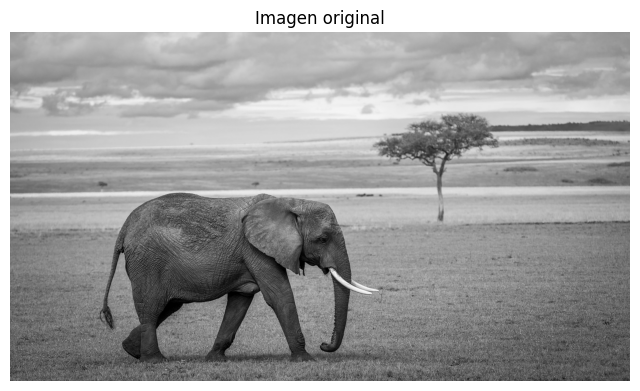

In [ ]:
img_path = "imagen.jpg"

img = Image.open(img_path)
print(f"Imagen cargada desde: {img_path}")

plt.imshow(img)
plt.axis("off")
plt.title("Imagen original")
plt.show()

## 2. Caracteristicas de la imagen

Datos a extraer:

- **Archivo**
- **Formato de archivo** (JPEG, PNG, BMP, etc.)
- **Tamaño en disco** (KB)
- **Modo de color** (RGB, escala de grises, RGBA, etc.)
- **Cantidad de canales**: 3 si es RGB
- **Profundidad de bits por canal**
- **Resolución espacial**: cantidad de píxeles en ancho x alto
- **Cantidad total de pixeles**: pixeles en ancho * pixeles en alto
- **Resolución radiométrica**: cantidad de niveles de intensidad posibles (2^bits)
- **¿Escala de grises?**: si la imagen es monocromática o si, siendo RGB, sus tres canales son iguales píxel a píxel
- **¿Esta en 8 bits?**
- **¿Luz visible?**: las cámaras y formatos de imagen estándar (JPEG/PNG/BMP tomados con cámara común) capturan el espectro visible (400-700nm aprox.)


In [ ]:
def extraer_caracteristicas(path):
    im = Image.open(path)
    arr = np.array(im)

    ancho, alto = im.size
    total_pixeles = ancho * alto
    modo = im.mode

    # Bits por canal según el modo de PIL
    bits_por_canal_dict = {
        "1": 1, "L": 8, "P": 8, "RGB": 8, "RGBA": 8,
        "CMYK": 8, "I": 32, "F": 32
    }
    bits_por_canal = bits_por_canal_dict.get(modo, 8)
    n_canales = len(im.getbands())
    bits_por_pixel = bits_por_canal * n_canales

    # ¿Escala de grises?
    if modo == "L" or modo == "1":
        es_grises = True
    elif modo in ("RGB", "RGBA"):
        rgb = arr[..., :3]
        es_grises = bool(np.all(rgb[..., 0] == rgb[..., 1]) and np.all(rgb[..., 1] == rgb[..., 2]))
    else:
        es_grises = False

    # Niveles de gris/intensidad realmente utilizados
    if es_grises:
        canal_intensidad = arr if arr.ndim == 2 else arr[..., 0]
    else:
        canal_intensidad = np.array(im.convert("L"))
    niveles_usados = len(np.unique(canal_intensidad))

    dpi = im.info.get("dpi", "No especificado en los metadatos")
    tamano_disco_kb = os.path.getsize(path) / 1024

    caracteristicas = {
        "Archivo": os.path.basename(path),
        "Formato": im.format,
        "Tamaño en disco (KB)": round(tamano_disco_kb, 2),
        "Modo de color": modo,
        "Cantidad de canales": n_canales,
        "Profundidad de bits por canal": bits_por_canal,
        "Resolución espacial (ancho x alto)": f"{ancho} x {alto} px",
        "Total de píxeles": total_pixeles,
        "Resolución radiométrica (niveles posibles)": 2 ** bits_por_canal,
        "¿Escala de grises?": "Sí" if es_grises else "No (imagen a color)",
        "¿8 bits o menos por canal?": "Sí" if bits_por_canal <= 8 else "No",
        "¿Luz visible?": "Sí, formato fotográfico estándar (RGB/gris) capturado en el espectro visible"
    }
    return caracteristicas, arr


caracteristicas, arr_original = extraer_caracteristicas(img_path)

print("=" * 60)
print("CARACTERÍSTICAS DE LA IMAGEN")
print("=" * 60)
for clave, valor in caracteristicas.items():
    print(f"{clave:45s}: {valor}")


CARACTERÍSTICAS DE LA IMAGEN
Archivo                                      : byn.jpg
Formato                                      : JPEG
Tamaño en disco (KB)                         : 239.19
Modo de color                                : RGB
Cantidad de canales                          : 3
Profundidad de bits por canal                : 8
Resolución espacial (ancho x alto)           : 1280 x 720 px
Total de píxeles                             : 921600
Resolución radiométrica (niveles posibles)   : 256
¿Escala de grises?                           : Sí
¿8 bits o menos por canal?                   : Sí
¿Luz visible?                                : Sí, formato fotográfico estándar (RGB/gris) capturado en el espectro visible


## 3. Reduccion resolucion espacial

In [ ]:
TAMAÑO = 500

Tamaño original            : 1280 x 720 px  (921600 píxeles)
Tamaño tras submuestreo     : 500 x 500 px  (250000 píxeles)
Tamaño mostrado en pantalla : 1280 x 720 px (igual al original, pero con menos información real)


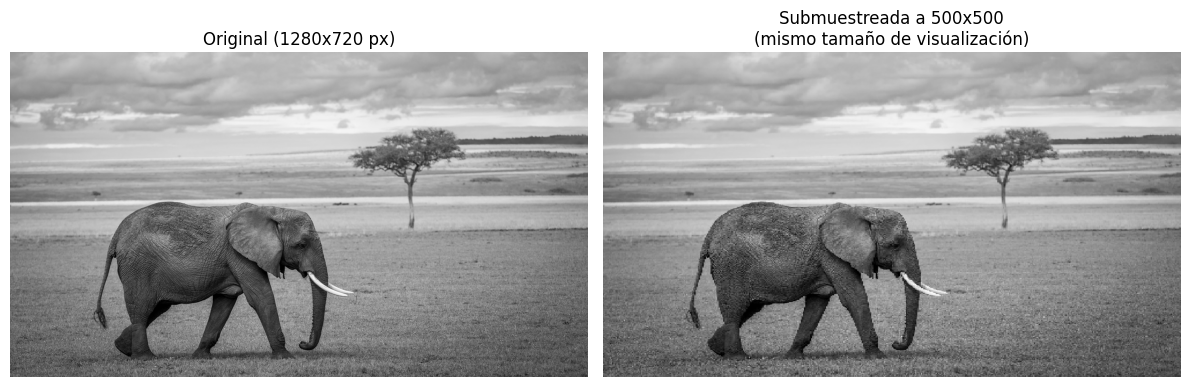

In [ ]:
def reducir_resolucion_espacial(imagen_pil, nuevo_ancho, nuevo_alto):
    """
    Reduce la cantidad de píxeles de la imagen (submuestreo) a (nuevo_ancho x nuevo_alto)
    y luego la reescala al tamaño original, usando NEAREST para no interpolar
    información nueva (efecto de píxeles grandes / pixelado).
    """
    tamano_original = imagen_pil.size  # (ancho, alto)
    submuestreada = imagen_pil.resize((nuevo_ancho, nuevo_alto), Image.NEAREST)
    reescalada = submuestreada.resize(tamano_original, Image.NEAREST)
    return submuestreada, reescalada


sub, img_mismo_tamano = reducir_resolucion_espacial(img, TAMAÑO, TAMAÑO)

print(f"Tamaño original            : {img.size[0]} x {img.size[1]} px  ({img.size[0]*img.size[1]} píxeles)")
print(f"Tamaño tras submuestreo     : {sub.size[0]} x {sub.size[1]} px  ({sub.size[0]*sub.size[1]} píxeles)")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title(f"Original ({img.size[0]}x{img.size[1]} px)")
axes[0].axis("off")

axes[1].imshow(img_mismo_tamano)
axes[1].set_title("Submuestreada a 500x500\n(mismo tamaño de visualización)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3.1 Submuestreo a distintas resoluciones

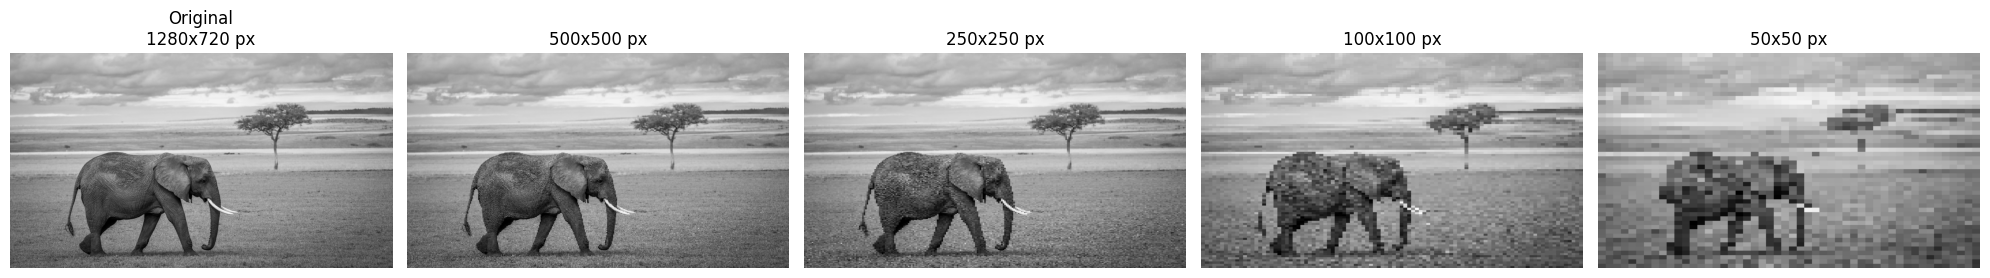

In [ ]:
tamanos = [500, 250, 100, 50]

fig, axes = plt.subplots(1, len(tamanos) + 1, figsize=(4 * (len(tamanos) + 1), 4))

axes[0].imshow(img)
axes[0].set_title(f"Original\n{img.size[0]}x{img.size[1]} px")
axes[0].axis("off")

for ax, n in zip(axes[1:], tamanos):
    _, reescalada = reducir_resolucion_espacial(img, n, n)
    ax.imshow(reescalada)
    ax.set_title(f"{n}x{n} px")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. Reduccion resolucion radiometrica

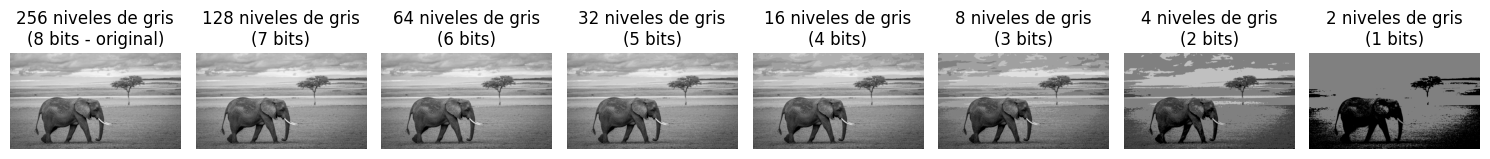

In [ ]:
def cuantizar(imagen_gris_array, niveles):
    """
    Reduce la resolución radiométrica de una imagen en escala de grises (0-255)
    a la cantidad de 'niveles' indicada, mediante cuantización uniforme.
    """
    paso = 256 / niveles
    cuantizada = (np.floor(imagen_gris_array / paso) * paso).astype(np.uint8)
    cuantizada = np.clip(cuantizada, 0, 255)
    return cuantizada

img_gris_original = np.array(img.convert("L"))

gris_256 = img_gris_original                       # 256 niveles (8 bits) - original
gris_128 = cuantizar(gris_256, 128)                 # mitad
gris_64  = cuantizar(gris_128, 64)                  # mitad de la mitad
gris_32  = cuantizar(gris_64, 32)
gris_16  = cuantizar(gris_32, 16)
gris_8  = cuantizar(gris_16, 8)
gris_4  = cuantizar(gris_8, 4)
gris_2  = cuantizar(gris_4, 2)

fig, axes = plt.subplots(1, 8, figsize=(15, 6))
axes[0].imshow(gris_256, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("256 niveles de gris\n(8 bits - original)")
axes[0].axis("off")

axes[1].imshow(gris_128, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("128 niveles de gris\n(7 bits)")
axes[1].axis("off")

axes[2].imshow(gris_64, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("64 niveles de gris\n(6 bits)")
axes[2].axis("off")

axes[3].imshow(gris_32, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("32 niveles de gris\n(5 bits)")
axes[3].axis("off")

axes[4].imshow(gris_16, cmap="gray", vmin=0, vmax=255)
axes[4].set_title("16 niveles de gris\n(4 bits)")
axes[4].axis("off")

axes[5].imshow(gris_8, cmap="gray", vmin=0, vmax=255)
axes[5].set_title("8 niveles de gris\n(3 bits)")
axes[5].axis("off")

axes[6].imshow(gris_4, cmap="gray", vmin=0, vmax=255)
axes[6].set_title("4 niveles de gris\n(2 bits)")
axes[6].axis("off")

axes[7].imshow(gris_2, cmap="gray", vmin=0, vmax=255)
axes[7].set_title("2 niveles de gris\n(1 bits)")
axes[7].axis("off")

plt.tight_layout()
plt.show()
